<a href="https://colab.research.google.com/github/Bharati-M/house-price-prediction-eda-linear-regression/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
#loding the dataset
df = pd.read_csv("/content/drive/MyDrive/kc_house_data.csv")
df.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [20]:
#to get datainformation
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_l

In [ ]:
#to check for missing value
df.isnull().sum()
df = df.dropna()

In [ ]:
#to check duplicate values
df.duplicated().sum()
#Remove duplicates if present:
df = df.drop_duplicates()

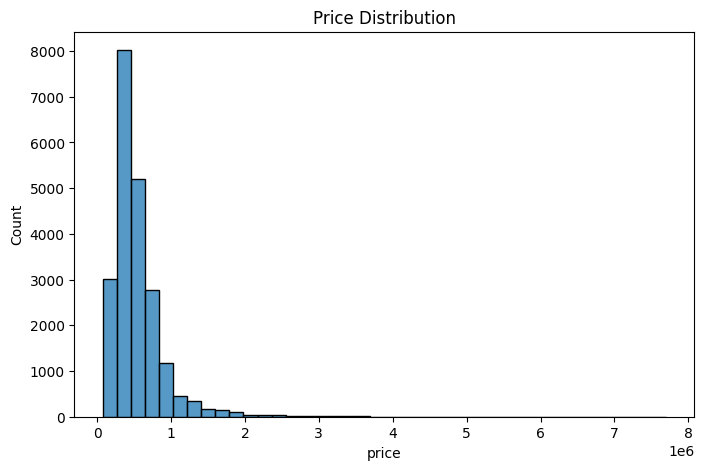

In [ ]:
#Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=40)
plt.title("Price Distribution")
plt.show()

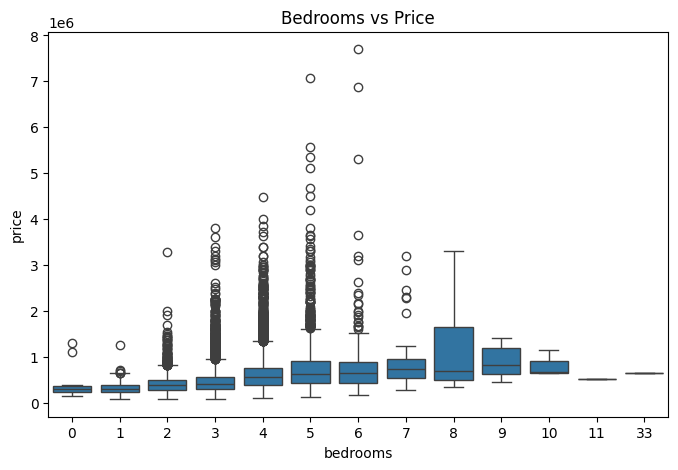

In [ ]:
#Bedrooms vs Price
plt.figure(figsize=(8,5))
sns.boxplot(x=df['bedrooms'], y=df['price'])
plt.title("Bedrooms vs Price")
plt.show()

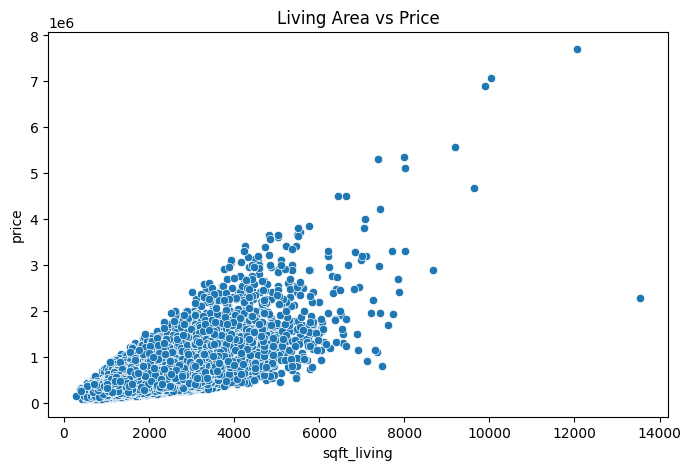

In [ ]:
#Living Area vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['sqft_living'], y=df['price'])
plt.title("Living Area vs Price")
plt.show()


In [ ]:
#Remove unnecessary columns
df = df.drop(['id','date'], axis=1)

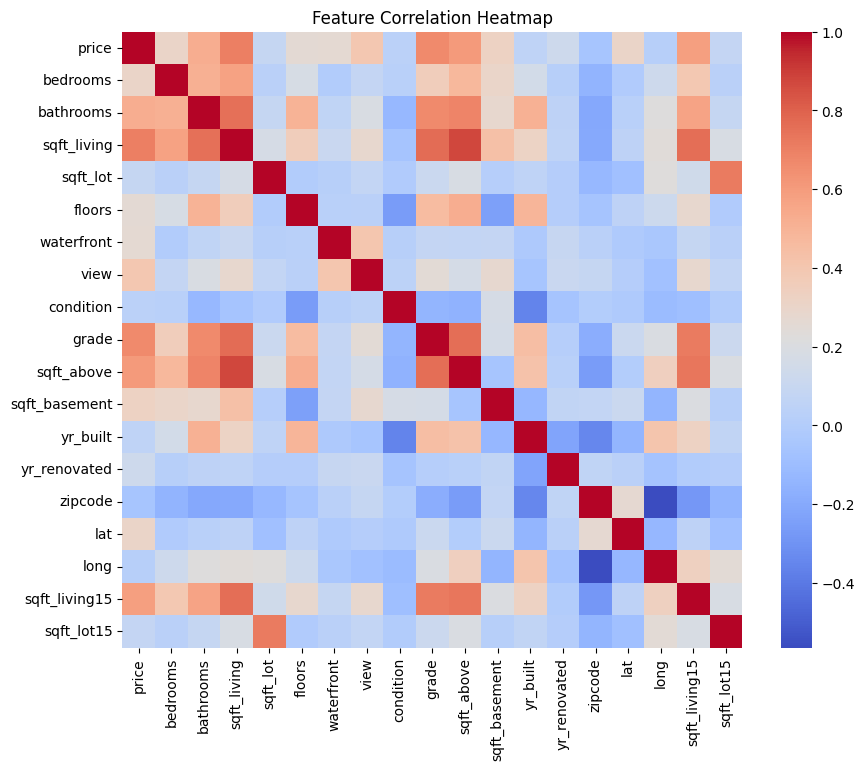

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
#Select features and target
X = df.drop('price', axis=1)
y = df['price']

In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Model Training (Linear Regression)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Prediction
y_pred = model.predict(X_test)

In [ ]:
#Model Evaluation(R² Score)
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)


R² Score: 0.7011904448878442


In [ ]:
#Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 127493.34208656367


In [ ]:
#Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 45173046132.7897


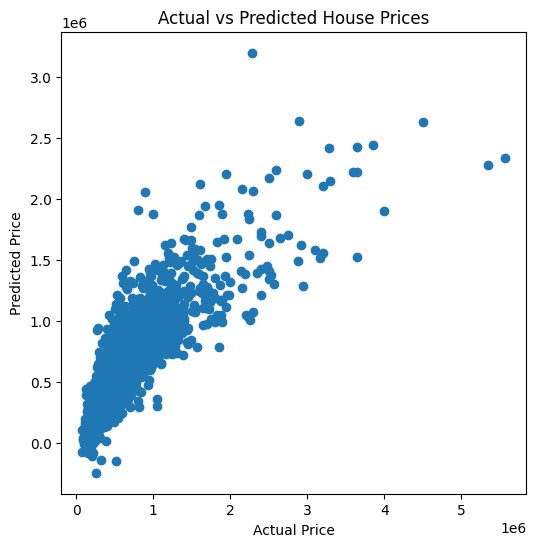

In [ ]:
#Prediction Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()
